In [2]:
import pandas as pd

In [3]:
temp = pd.read_csv("/Users/fangsiyu/Desktop/sdu-2026-code/804_data_mining/project_1/set1.txt",
            sep=r"\s+",
            header=None)
temp = temp.rename(columns={2:"cluster"})
temp.to_csv("/Users/fangsiyu/Desktop/sdu-2026-code/804_data_mining/project_1/cleaned_p1.csv")

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans




# 1. do standarlize, cuz we r using L2 to count the distance 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 2. build model and train, get predict

# 2.1 
kmeans_lloyd = KMeans(n_clusters=3, init='random', algorithm='lloyd', random_state=42)
labels_lloyd = kmeans_lloyd.fit_predict(X_scaled)

# 2.2
mbk = MiniBatchKMeans(
    n_clusters=3,
    init='random',
    batch_size=1,
    max_iter=100,
    random_state=42
)
labels_mq = mbk.fit_predict(X_scaled)

# 2.3
kmeans_elkan = KMeans(n_clusters=3, init='random', algorithm='elkan', random_state=42)
labels_elkan = kmeans_elkan.fit_predict(X_scaled)

# 2.4
kmeans_k_plus = KMeans(n_clusters=3, init='k-means++', algorithm='lloyd', random_state=42)
labels_k_plus = kmeans_k_plus.fit_predict(X_scaled)

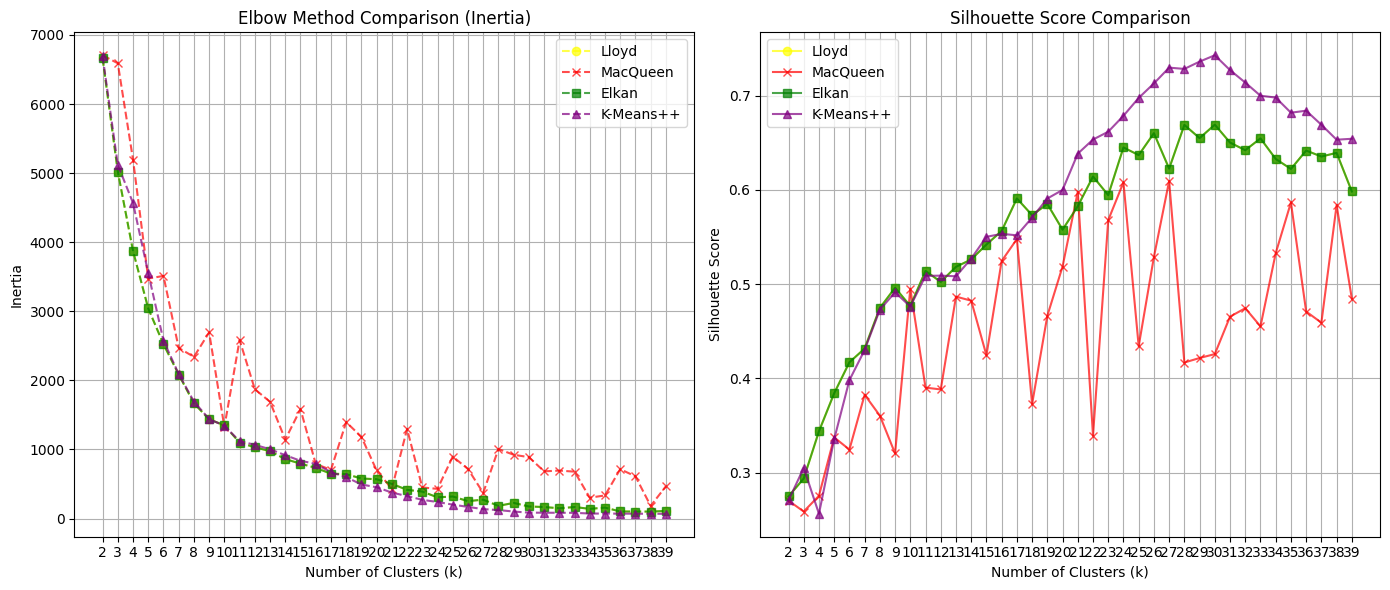

In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 40)

results = {
    'Lloyd':      {'inertia': [], 'silhouette': [], 'color': 'yellow',   'marker': 'o'},
    'MacQueen':   {'inertia': [], 'silhouette': [], 'color': 'red',    'marker': 'x'},
    'Elkan':      {'inertia': [], 'silhouette': [], 'color': 'green',  'marker': 's'},
    'K-Means++':  {'inertia': [], 'silhouette': [], 'color': 'purple', 'marker': '^'}
}

for k in k_range:
    # 1. Lloyd - note that Lloyd & Elkan are ganna overlapped
    kmeans_lloyd = KMeans(n_clusters=k, init='random', algorithm='lloyd', random_state=42)
    labels_lloyd = kmeans_lloyd.fit_predict(X_scaled)
    results['Lloyd']['inertia'].append(kmeans_lloyd.inertia_)
    results['Lloyd']['silhouette'].append(silhouette_score(X_scaled, labels_lloyd))
    
    # 2. MacQueen
    mbk = MiniBatchKMeans(n_clusters=k, init='random', batch_size=1, max_iter=100, random_state=42)
    labels_mq = mbk.fit_predict(X_scaled)
    results['MacQueen']['inertia'].append(mbk.inertia_)
    results['MacQueen']['silhouette'].append(silhouette_score(X_scaled, labels_mq))
    
    # # 3. Elkan
    kmeans_elkan = KMeans(n_clusters=k, init='random', algorithm='elkan', random_state=42)
    labels_elkan = kmeans_elkan.fit_predict(X_scaled)
    results['Elkan']['inertia'].append(kmeans_elkan.inertia_)
    results['Elkan']['silhouette'].append(silhouette_score(X_scaled, labels_elkan))

    # 4. K-Means++
    kmeans_k_plus = KMeans(n_clusters=k, init='k-means++', algorithm='lloyd', random_state=42)
    labels_k_plus = kmeans_k_plus.fit_predict(X_scaled)
    results['K-Means++']['inertia'].append(kmeans_k_plus.inertia_)
    results['K-Means++']['silhouette'].append(silhouette_score(X_scaled, labels_k_plus))


# ========== 視覺化大亂鬥 ==========
plt.figure(figsize=(14, 6))

# 第一張圖：Elbow Method (Inertia)
plt.subplot(1, 2, 1)
for name, data in results.items():
    plt.plot(k_range, data['inertia'], marker=data['marker'], color=data['color'], label=name, linestyle='--', alpha=0.7)
plt.title('Elbow Method Comparison (Inertia)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.legend()
plt.grid(True)

# 第二張圖：Silhouette Score
plt.subplot(1, 2, 2)
for name, data in results.items():
    plt.plot(k_range, data['silhouette'], marker=data['marker'], color=data['color'], label=name, linestyle='-', alpha=0.7)
plt.title('Silhouette Score Comparison')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

sample_size=1000, 
score = silhouette_score(X_scaled, labels, sample_size=1000, random_state=42)
他說超過5w 再來考慮坐著 sample

In [6]:
from sklearn.metrics import silhouette_score

labels_lloyd_score = silhouette_score(X_scaled, labels_lloyd)
labels_mq_score = silhouette_score(X_scaled, labels_mq)
labels_elkan_score = silhouette_score(X_scaled, labels_elkan)
labels_k_plus_score = silhouette_score(X_scaled, labels_k_plus)

print("silhouette_score - lloyd_score: ", labels_lloyd_score)
print("silhouette_score - mq_score:    ", labels_mq_score)
print("silhouette_score - elkan_score: ", labels_elkan_score)
print("silhouette_score - k_plus_score:", labels_k_plus_score)

silhouette_score - lloyd_score:  0.5983304390084825
silhouette_score - mq_score:     0.48470308791232547
silhouette_score - elkan_score:  0.5983304390084825
silhouette_score - k_plus_score: 0.6541717212154174


In [7]:
from sklearn.metrics import adjusted_rand_score

y_true = pd.read_csv("/Users/fangsiyu/Desktop/sdu-2026-code/804_data_mining/project_1/cleaned_p1.csv")["cluster"]

ari_lloyd = adjusted_rand_score(y_true, labels_lloyd)
ari_mq = adjusted_rand_score(y_true, labels_mq)
ari_elkan = adjusted_rand_score(y_true, labels_elkan)
ari_k_plus = adjusted_rand_score(y_true, labels_k_plus)

print("ARI - Lloyd:      ", ari_lloyd)
print("ARI - MacQueen:   ", ari_mq)
print("ARI - Elkan:      ", ari_elkan)
print("ARI - K-Means++:  ", ari_k_plus)

ARI - Lloyd:       0.8918978263348464
ARI - MacQueen:    0.773951543100156
ARI - Elkan:       0.8918978263348464
ARI - K-Means++:   0.9415025800418929


# ==========================================================================================
# EM Clustering
# ==========================================================================================

In [8]:
from sklearn.mixture import GaussianMixture


em_model = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
labels_em = em_model.fit_predict(X_scaled)

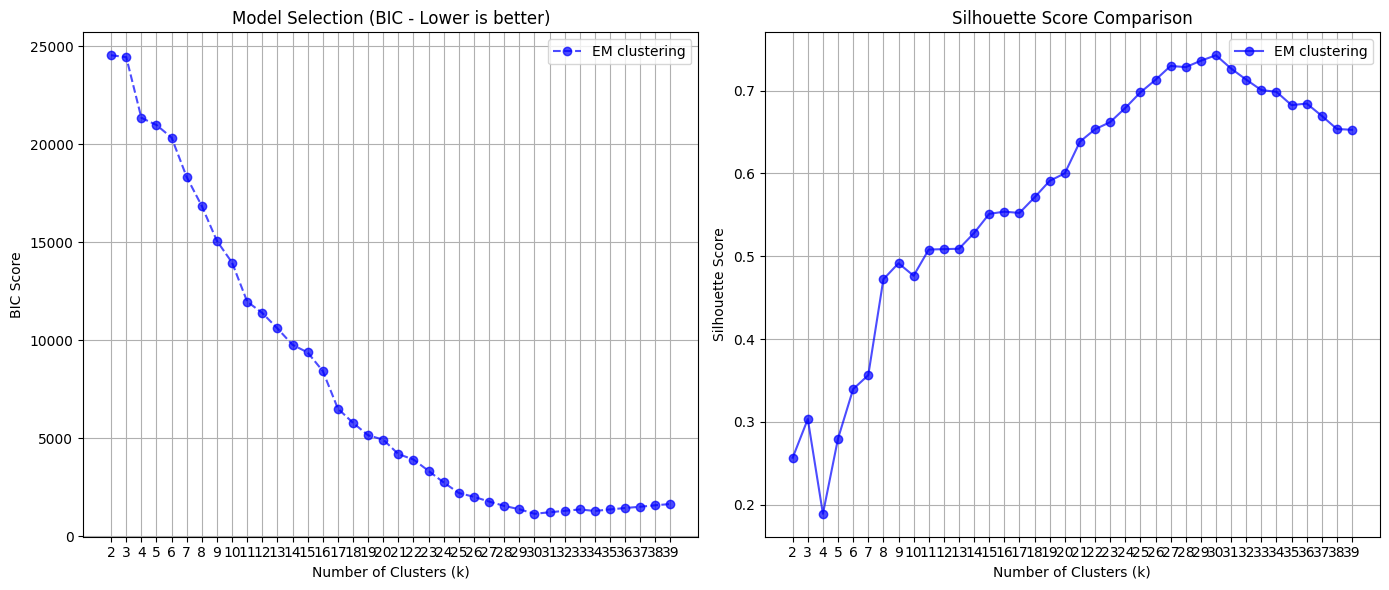

In [9]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

k_range = range(2, 40)

results = {
    'EM clustering': {'bic': [], 'silhouette': [], 'color': 'blue', 'marker': 'o'},
}

for k in k_range:
    em_model = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    labels_em = em_model.fit_predict(X_scaled)

    results['EM clustering']['bic'].append(em_model.bic(X_scaled))
    results['EM clustering']['silhouette'].append(silhouette_score(X_scaled, labels_em))
    

# ========== 視覺化大亂鬥 ==========
plt.figure(figsize=(14, 6))

# 第一張圖：使用 BIC 取代 Inertia
plt.subplot(1, 2, 1)
for name, data in results.items():
    plt.plot(k_range, data['bic'], marker=data['marker'], color=data['color'], label=name, linestyle='--', alpha=0.7)
plt.title('Model Selection (BIC - Lower is better)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('BIC Score')
plt.xticks(k_range)
plt.legend()
plt.grid(True)

# 第二張圖：Silhouette Score (維持不變)
plt.subplot(1, 2, 2)
for name, data in results.items():
    plt.plot(k_range, data['silhouette'], marker=data['marker'], color=data['color'], label=name, linestyle='-', alpha=0.7)
plt.title('Silhouette Score Comparison')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
labels_em_score = silhouette_score(X_scaled, labels_em)
ari_em = adjusted_rand_score(y_true, labels_em)

print("silhouette_score - lloyd_score:", labels_em_score)
print("ARI - EM (GMM):                ", ari_lloyd)

silhouette_score - lloyd_score: 0.6526492508215622
ARI - EM (GMM):                 0.8918978263348464


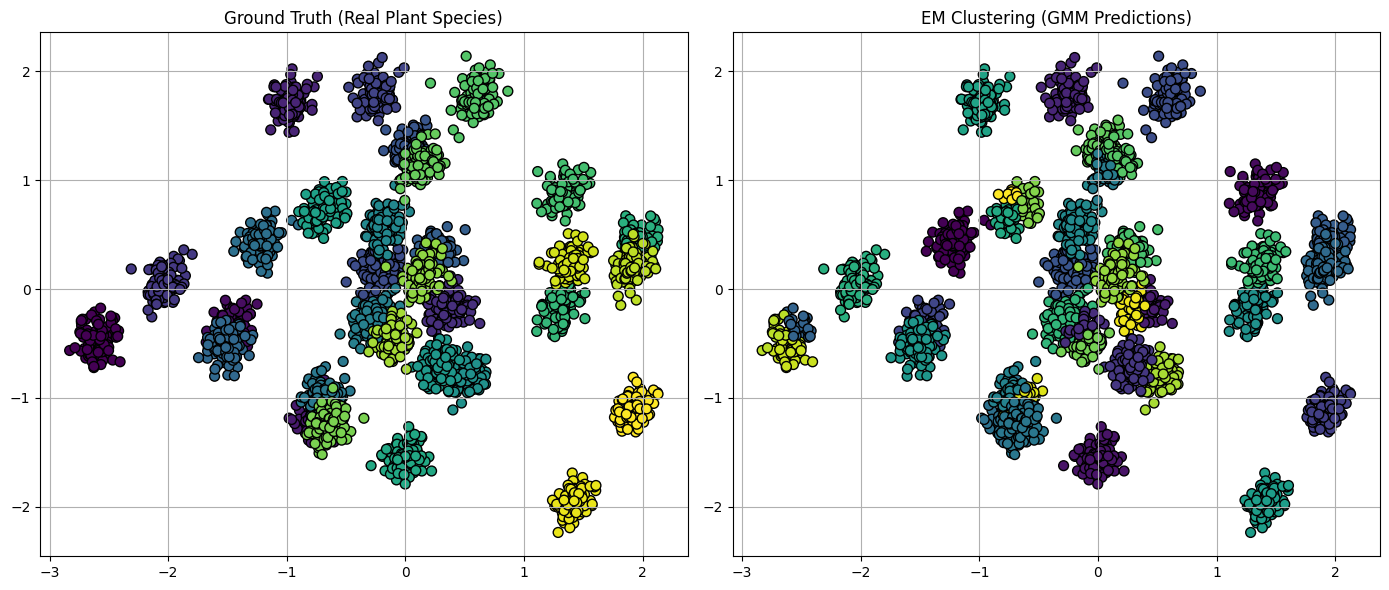

In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA twist 7 dimension into 2 dimension
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter_true = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', edgecolor='k', s=50)
axes[0].set_title('Ground Truth (Real Plant Species)')
axes[0].grid(True)

scatter_em = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_em, cmap='viridis', edgecolor='k', s=50)
axes[1].set_title('EM Clustering (GMM Predictions)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [12]:
# OPT for EM Clustering

from sklearn.mixture import BayesianGaussianMixture
import numpy as np

# 1. Initialize with an intentionally high k (e.g., 10) assuming true k is unknown.
# A low 'weight_concentration_prior' forces the model to drop unnecessary clusters 
# by pushing their weights to near zero.
bgm = BayesianGaussianMixture(
    n_components=100, 
    covariance_type='full', 
    weight_concentration_prior=0.01, 
    random_state=42
)

# 2. Train the model and get predictions
labels_bgm = bgm.fit_predict(X_scaled)

# 3. Extract and display the weight of each cluster (rounded to 3 decimals)
weights = bgm.weights_
print("Weights assigned to the 10 clusters:")
print(np.round(weights, 3))

# 4. Infer the optimal k by counting clusters with weights above a threshold (e.g., 10%)
active_clusters = sum(weights > 0.015)
print(f"\nBGM inferred {active_clusters} effective clusters for this dataset.")

Weights assigned to the 10 clusters:
[0.    0.033 0.    0.    0.    0.    0.    0.    0.    0.032 0.    0.
 0.032 0.065 0.    0.    0.    0.032 0.    0.    0.032 0.    0.    0.
 0.032 0.032 0.032 0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.064 0.    0.032 0.032 0.    0.032 0.032 0.    0.    0.    0.032 0.
 0.032 0.032 0.    0.    0.    0.    0.    0.032 0.    0.    0.    0.
 0.    0.    0.031 0.    0.031 0.    0.    0.    0.    0.    0.031 0.
 0.    0.    0.031 0.    0.031 0.031 0.061 0.031 0.    0.    0.    0.03
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.026 0.    0.    0.   ]

BGM inferred 28 effective clusters for this dataset.


# ==========================================================================================
# DBSCAN
# ==========================================================================================

In [15]:
import optuna
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score
import hdbscan # Required for DBCV metric
import numpy as np
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

def objective_dbscan(trial):
    # 1. Suggest parameters for traditional DBSCAN
    eps_trial = trial.suggest_float('eps', 0.1, 2.0)
    min_samples_trial = trial.suggest_int('min_samples', 2, 15)
    
    # 2. Train model
    dbscan = DBSCAN(eps=eps_trial, min_samples=min_samples_trial)
    labels = dbscan.fit_predict(X_scaled)
    
    # 3. Guardrail: Ensure at least 2 valid clusters exist (excluding noise)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        return -1.0 
        
    # 4. Target Metric: Maximize DBCV
    try:
        score = hdbscan.validity.validity_index(X_scaled, labels)
    except ValueError:
        # Failsafe for invalid cluster structures
        return -1.0
        
    return score

print("=== Starting Optuna for Traditional DBSCAN ===")
optuna.logging.set_verbosity(optuna.logging.WARNING) 
study_dbscan = optuna.create_study(direction="maximize")
study_dbscan.optimize(objective_dbscan, n_trials=50)

best_eps = study_dbscan.best_params['eps']
best_min = study_dbscan.best_params['min_samples']

print(f"\n[Best Params] eps: {best_eps:.4f}, min_samples: {best_min}")

# Final evaluation with best parameters
final_dbscan = DBSCAN(eps=best_eps, min_samples=best_min)
labels_dbscan = final_dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_db = list(labels_dbscan).count(-1)

print(f"-> Valid Clusters: {n_clusters_db} | Noise Points: {n_noise_db}")
print(f"-> ARI: {adjusted_rand_score(y_true, labels_dbscan):.4f}")
print(f"-> DBCV: {hdbscan.validity.validity_index(X_scaled, labels_dbscan):.4f} (Primary Target)")
print(f"-> Silhouette: {silhouette_score(X_scaled, labels_dbscan):.4f} [Reference Only]\n")

=== Starting Optuna for Traditional DBSCAN ===

[Best Params] eps: 0.2841, min_samples: 14
-> Valid Clusters: 27 | Noise Points: 0
-> ARI: 0.8804
-> DBCV: 0.6912 (Primary Target)
-> Silhouette: 0.7298 [Reference Only]



In [16]:
import optuna
# Import HDBSCAN directly from sklearn (Requires sklearn >= 1.3.0)
from sklearn.cluster import HDBSCAN 
from sklearn.metrics import adjusted_rand_score, silhouette_score
import hdbscan # Still required ONLY for the DBCV metric
import numpy as np
import warnings

warnings.filterwarnings("ignore")

def objective_hdbscan(trial):
    # 1. Suggest parameters for HDBSCAN
    # min_cluster_size is the primary parameter. We search between 2 and 15.
    min_cluster_size_trial = trial.suggest_int('min_cluster_size', 2, 15)
    
    # 2. Train model
    hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size_trial)
    labels = hdbscan_model.fit_predict(X_scaled)
    
    # 3. Guardrail: Ensure at least 2 valid clusters exist
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        return -1.0 
        
    # 4. Target Metric: Maximize DBCV
    try:
        score = hdbscan.validity.validity_index(X_scaled, labels)
    except ValueError:
        return -1.0
        
    return score

print("=== Starting Optuna for Modern HDBSCAN ===")
optuna.logging.set_verbosity(optuna.logging.WARNING) 
study_hdbscan = optuna.create_study(direction="maximize")
# We only need 20 trials here because the search space is much smaller (just one integer)
study_hdbscan.optimize(objective_hdbscan, n_trials=20)

best_min_cluster = study_hdbscan.best_params['min_cluster_size']

print(f"\n[Best Params] min_cluster_size: {best_min_cluster}")

# Final evaluation with best parameters
final_hdbscan = HDBSCAN(min_cluster_size=best_min_cluster)
labels_hdbscan = final_hdbscan.fit_predict(X_scaled)

n_clusters_hdb = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
n_noise_hdb = list(labels_hdbscan).count(-1)

print(f"-> Valid Clusters: {n_clusters_hdb} | Noise Points: {n_noise_hdb}")
print(f"-> ARI: {adjusted_rand_score(y_true, labels_hdbscan):.4f}")
print(f"-> DBCV: {hdbscan.validity.validity_index(X_scaled, labels_hdbscan):.4f} (Primary Target)")
# Try-except block for Silhouette because HDBSCAN might classify EVERYTHING as noise (-1) in edge cases
try:
    sil_score = silhouette_score(X_scaled, labels_hdbscan)
    print(f"-> Silhouette: {sil_score:.4f} [Reference Only]\n")
except ValueError:
    print("-> Silhouette: N/A (Only 1 cluster or all noise)\n")

=== Starting Optuna for Modern HDBSCAN ===

[Best Params] min_cluster_size: 12
-> Valid Clusters: 30 | Noise Points: 25
-> ARI: 0.9573
-> DBCV: 0.6771 (Primary Target)
-> Silhouette: 0.7342 [Reference Only]

